### Deep Learning — Complete Interview Preparation Notebook (PyTorch)

**Comprehensive reference covering PyTorch, CNNs, RNNs, Transformers, OpenCV, HuggingFace, and SentenceTransformers**


---

#### Table of Contents

1. [DL Fundamentals — Neurons, Activations, Loss Functions](#dl-fundamentals)
2. [Optimizers and Learning Rate Scheduling](#optimizers)
3. [PyTorch Core — Tensors, Autograd, nn.Module](#pytorch-core)
4. [PyTorch Training Loop and Custom Datasets](#pytorch-training)
5. [CNNs — Convolutional Neural Networks](#cnns)
6. [Transfer Learning and Fine-Tuning](#transfer-learning)
7. [RNNs, LSTMs, and GRUs](#rnns)
8. [Attention Mechanism and Transformers](#transformers)
9. [OpenCV — Computer Vision Basics](#opencv)
10. [HuggingFace Transformers Library](#huggingface)
11. [SentenceTransformers — Embeddings](#sentence-transformers)
12. [DL Fundamentals Interview Questions](#dl-fundamentals-qa)
13. [PyTorch Interview Questions](#pytorch-qa)
14. [CNN and RNN Interview Questions](#cnn-rnn-qa)
15. [Transformers Interview Questions](#transformers-qa)
16. [Computer Vision Interview Questions](#cv-qa)
17. [Master Interview Cheat Sheet](#master-cheatsheet)

<div style="text-align:center">
<img src="https://cs231n.github.io/assets/nn1/neural_net2.jpeg" width="450" />
<br><em>Neural Network — Input → Hidden Layers → Output</em>
</div>


---

#### Environment Setup

In [99]:
# ──────────────────────────────────────────────
# Install required packages (run once)
# ──────────────────────────────────────────────
# !pip install -q torch torchvision torchaudio
# !pip install -q opencv-python-headless pillow
# !pip install -q transformers sentence-transformers
# !pip install -q matplotlib seaborn numpy pandas scikit-learn

In [100]:
# ──────────────────────────────────────────────
# Core Imports
# ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"NumPy: {np.__version__}")

PyTorch: 2.10.0
CUDA available: False
NumPy: 2.3.4


---

<a id="dl-fundamentals"></a>

### Part 1: Deep Learning Fundamentals

#### Artificial Neuron (Perceptron)

A single neuron computes:

$$z = \sum_{i=1}^{n} w_i x_i + b = \mathbf{w}^T \mathbf{x} + b$$

$$\hat{y} = \sigma(z) = \text{activation}(z)$$

---

#### Activation Functions

| Function | Formula (LaTeX) | Range | Use Case |
| --- | --- | --- | --- |
| **Sigmoid** | $\sigma(x) = \frac{1}{1 + e^{-x}}$ | $(0, 1)$ | Binary classification output |
| **Tanh** | $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$ | $(-1, 1)$ | Hidden layers (zero-centered) |
| **ReLU** | $f(x) = \max(0, x)$ | $[0, \infty)$ | Default for hidden layers |
| **Leaky ReLU** | $f(x) = \max(\alpha x, x)$ where $\alpha = 0.01$ | $(-\infty, \infty)$ | Fixes dying ReLU |
| **ELU** | $f(x) = x$ if $x>0$, $\alpha(e^x - 1)$ if $x \leq 0$ | $(-\alpha, \infty)$ | Smoother than ReLU |
| **GELU** | $f(x) = x \cdot \Phi(x)$ where $\Phi$ is CDF of $\mathcal{N}(0,1)$ | $(-\infty, \infty)$ | Transformers (BERT, GPT) |
| **Swish/SiLU** | $f(x) = x \cdot \sigma(x)$ | $(-\infty, \infty)$ | Modern architectures |
| **Softmax** | $\sigma(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$ | $(0, 1)$, sums to 1 | Multi-class output |

---

#### Loss Functions

| Loss | Formula | Use Case |
| --- | --- | --- |
| **MSE** | $\mathcal{L} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$ | Regression |
| **MAE** | $\mathcal{L} = \frac{1}{n}\sum_{i=1}^{n}\lvert y_i - \hat{y}_i \rvert$ | Regression (robust to outliers) |
| **Binary Cross-Entropy** | $\mathcal{L} = -\frac{1}{n}\sum[y\log(\hat{y}) + (1-y)\log(1-\hat{y})]$ | Binary classification |
| **Cross-Entropy** | $\mathcal{L} = -\sum_{c=1}^{C} y_c \log(\hat{y}_c)$ | Multi-class classification |
| **Focal Loss** | $\mathcal{L} = -\alpha_t (1 - p_t)^\gamma \log(p_t)$ | Imbalanced classification |
| **Huber Loss** | Quadratic for small errors, linear for large | Robust regression |
| **KL Divergence** | $D_{KL}(P \Vert Q) = \sum P(x) \log\frac{P(x)}{Q(x)}$ | VAEs, knowledge distillation |
| **Triplet Loss** | $\mathcal{L} = \max(d(a,p) - d(a,n) + \text{margin}, 0)$ | Metric learning, face recognition |
| **Contrastive Loss** | $\mathcal{L} = yd^2 + (1-y)\max(\text{margin} - d, 0)^2$ | Siamese networks |

---

#### Backpropagation — Chain Rule

$$\frac{\partial \mathcal{L}}{\partial w} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w}$$

**Gradient descent update**: $w \leftarrow w - \eta \frac{\partial \mathcal{L}}{\partial w}$

**Vanishing gradient**: When $\frac{\partial \hat{y}}{\partial z} \approx 0$ (sigmoid saturation), gradients vanish.

**Exploding gradient**: When gradients grow exponentially through layers. Fix: gradient clipping.

---

#### Regularization Techniques

| Technique | Formula / Detail | Effect |
| --- | --- | --- |
| **L2 (Weight Decay)** | $\mathcal{L}_{total} = \mathcal{L} + \lambda \sum w_i^2$ | Penalizes large weights |
| **L1** | $\mathcal{L}_{total} = \mathcal{L} + \lambda \sum \lvert w_i \rvert$ | Sparsity (some weights → 0) |
| **Dropout** | Randomly zero out neurons with probability $p$ | Prevents co-adaptation |
| **Batch Normalization** | $\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}} \cdot \gamma + \beta$ | Stabilizes training |
| **Layer Normalization** | Normalize across features (not batch) | Used in Transformers |
| **Early Stopping** | Stop when validation loss increases | Prevents overfitting |
| **Data Augmentation** | Random transforms on training data | Artificially larger dataset |


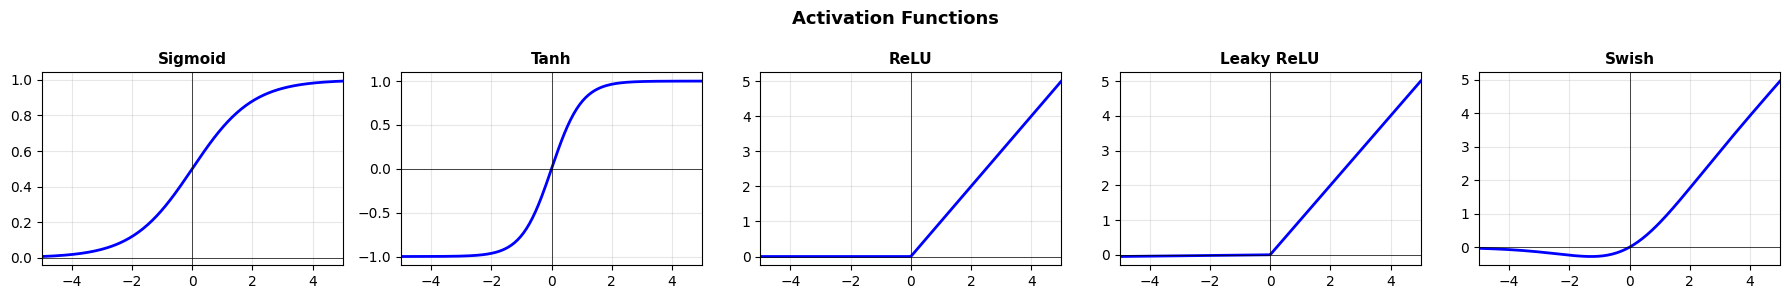

In [101]:
# ──────────────────────────────────────────────
# Activation Functions Visualization
# ──────────────────────────────────────────────
x = np.linspace(-5, 5, 200)

activations = {
    'Sigmoid': 1 / (1 + np.exp(-x)),
    'Tanh': np.tanh(x),
    'ReLU': np.maximum(0, x),
    'Leaky ReLU': np.where(x > 0, x, 0.01 * x),
    'Swish': x * (1 / (1 + np.exp(-x))),
}

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax, (name, y) in zip(axes, activations.items()):
    ax.plot(x, y, 'b-', linewidth=2)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlim(-5, 5)
    ax.grid(True, alpha=0.3)

plt.suptitle('Activation Functions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

<a id="optimizers"></a>

#### Optimizers — Update Rules

| Optimizer | Update Rule | Key Idea |
| --- | --- | --- |
| **SGD** | $w \leftarrow w - \eta \nabla \mathcal{L}$ | Simple gradient descent |
| **SGD + Momentum** | $v_t = \beta v_{t-1} + \nabla\mathcal{L}$, $w \leftarrow w - \eta v_t$ | Accumulates velocity |
| **RMSprop** | $s_t = \beta s_{t-1} + (1-\beta)(\nabla\mathcal{L})^2$, $w \leftarrow w - \frac{\eta}{\sqrt{s_t + \epsilon}} \nabla\mathcal{L}$ | Adaptive lr per param |
| **Adam** | Combines momentum ($m_t$) + RMSprop ($v_t$) with bias correction | Best default optimizer |
| **AdamW** | Adam + decoupled weight decay: $w \leftarrow w - \lambda w$ | Better generalization |

**Adam full equations:**

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t \quad \text{(1st moment — mean)}$$

$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \quad \text{(2nd moment — variance)}$$

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t} \quad \text{(bias correction)}$$

$$w \leftarrow w - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

Default: $\beta_1 = 0.9, \beta_2 = 0.999, \epsilon = 10^{-8}$

---

#### Learning Rate Scheduling

| Schedule | Behavior | When to Use |
| --- | --- | --- |
| **StepLR** | Decrease by $\gamma$ every `step_size` epochs | Known training length |
| **CosineAnnealing** | $\eta_t = \eta_{min} + \frac{1}{2}(\eta_{max} - \eta_{min})(1 + \cos(\frac{t}{T}\pi))$ | Smooth decay |
| **ReduceLROnPlateau** | Reduce when val loss plateaus | Adaptive |
| **OneCycleLR** | Warmup → max → decay | Fast convergence (super-convergence) |
| **Warmup + Cosine** | Linear warmup then cosine decay | Transformers (standard) |


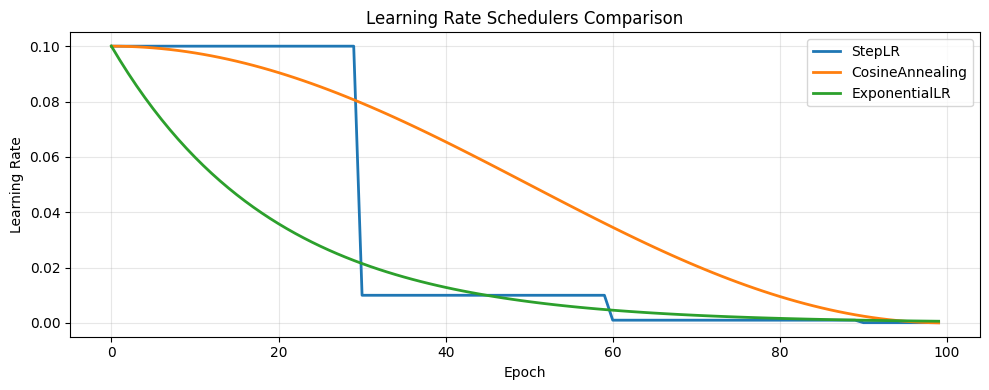

In [102]:
# ──────────────────────────────────────────────
# Learning Rate Schedulers Visualization
# ──────────────────────────────────────────────
epochs = 100
dummy_model = nn.Linear(1, 1)

schedules = {}

# StepLR
opt = optim.SGD(dummy_model.parameters(), lr=0.1)
sched = optim.lr_scheduler.StepLR(opt, step_size=30, gamma=0.1)
lrs = []
for _ in range(epochs):
    lrs.append(opt.param_groups[0]['lr'])
    sched.step()
schedules['StepLR'] = lrs

# CosineAnnealing
opt = optim.SGD(dummy_model.parameters(), lr=0.1)
sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
lrs = []
for _ in range(epochs):
    lrs.append(opt.param_groups[0]['lr'])
    sched.step()
schedules['CosineAnnealing'] = lrs

# ExponentialLR
opt = optim.SGD(dummy_model.parameters(), lr=0.1)
sched = optim.lr_scheduler.ExponentialLR(opt, gamma=0.95)
lrs = []
for _ in range(epochs):
    lrs.append(opt.param_groups[0]['lr'])
    sched.step()
schedules['ExponentialLR'] = lrs

fig, ax = plt.subplots(figsize=(10, 4))
for name, lrs in schedules.items():
    ax.plot(lrs, label=name, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedulers Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

<a id="pytorch-core"></a>

### Part 2: PyTorch Core — Tensors, Autograd, nn.Module

#### PyTorch Key Concepts

| Concept | Description |
| --- | --- |
| **Tensor** | Multi-dimensional array (like numpy ndarray but with GPU support + autograd) |
| **Autograd** | Automatic differentiation; tracks operations on tensors with requires_grad=True |
| **nn.Module** | Base class for all neural network modules; override forward() |
| **DataLoader** | Batching, shuffling, multiprocessing for data loading |
| **Optimizer** | Updates model parameters based on gradients (SGD, Adam, AdamW) |
| **Loss function** | Computes scalar loss for backpropagation |

In [103]:
# ──────────────────────────────────────────────
# PyTorch Tensors — Basics
# ──────────────────────────────────────────────

# Creating tensors
t1 = torch.tensor([1, 2, 3])                    # from list
t2 = torch.zeros(3, 4)                           # zeros
t3 = torch.ones(2, 3)                             # ones
t4 = torch.randn(3, 3)                            # random normal
t5 = torch.arange(0, 10, 2)                       # range
t6 = torch.linspace(0, 1, 5)                      # linearly spaced

print("Tensor from list:", t1)
print("Shape:", t4.shape, "Dtype:", t4.dtype, "Device:", t4.device)

# From numpy
arr = np.array([1.0, 2.0, 3.0])
t_from_np = torch.from_numpy(arr)
back_to_np = t_from_np.numpy()
print(f"\nNumpy <-> Tensor: {t_from_np}")

# Operations
a = torch.tensor([[1, 2], [3, 4]], dtype=torch.float)
b = torch.tensor([[5, 6], [7, 8]], dtype=torch.float)
print(f"\nAddition: {(a + b)}")
print(f"Matrix multiply: {(a @ b)}")
print(f"Element-wise: {(a * b)}")

# Reshaping
t = torch.arange(12)
print(f"\nReshape: {t.shape} -> {t.reshape(3, 4).shape}")
print(f"Unsqueeze: {t.unsqueeze(0).shape}")  # add batch dim

Tensor from list: tensor([1, 2, 3])
Shape: torch.Size([3, 3]) Dtype: torch.float32 Device: cpu

Numpy <-> Tensor: tensor([1., 2., 3.], dtype=torch.float64)

Addition: tensor([[ 6.,  8.],
        [10., 12.]])
Matrix multiply: tensor([[19., 22.],
        [43., 50.]])
Element-wise: tensor([[ 5., 12.],
        [21., 32.]])

Reshape: torch.Size([12]) -> torch.Size([3, 4])
Unsqueeze: torch.Size([1, 12])


In [104]:
# ──────────────────────────────────────────────
# Autograd — Automatic Differentiation
# ──────────────────────────────────────────────

# Simple gradient computation
x = torch.tensor(3.0, requires_grad=True)
y = x**2 + 2*x + 1  # y = x^2 + 2x + 1
y.backward()          # dy/dx = 2x + 2 = 8
print(f"x = {x.item()}, y = {y.item()}, dy/dx = {x.grad.item()}")

# Gradient for a vector
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y = (x ** 2).sum()
y.backward()
print(f"\nx = {x.data}, dy/dx = {x.grad}")  # [2, 4, 6]

# Detaching from computation graph
x = torch.randn(3, requires_grad=True)
y = x * 2
z = y.detach()  # z shares data but no grad tracking
print(f"\ny requires_grad: {y.requires_grad}")
print(f"z requires_grad: {z.requires_grad}")

# No grad context (inference)
with torch.no_grad():
    y = x * 2
    print(f"Inside no_grad: requires_grad = {y.requires_grad}")

x = 3.0, y = 16.0, dy/dx = 8.0

x = tensor([1., 2., 3.]), dy/dx = tensor([2., 4., 6.])

y requires_grad: True
z requires_grad: False
Inside no_grad: requires_grad = False


In [105]:
# ──────────────────────────────────────────────
# nn.Module — Building Neural Networks
# ──────────────────────────────────────────────

class SimpleNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = SimpleNet(input_dim=30, hidden_dim=64, output_dim=2)
print("Model architecture:")
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable: {trainable:,}")

# Forward pass
x_dummy = torch.randn(5, 30)
output = model(x_dummy)
print(f"\nInput shape: {x_dummy.shape}")
print(f"Output shape: {output.shape}")

Model architecture:
SimpleNet(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
)

Total parameters: 6,274
Trainable: 6,274

Input shape: torch.Size([5, 30])
Output shape: torch.Size([5, 2])


---

<a id="pytorch-training"></a>

#### PyTorch Training Loop — Complete Pattern

```
for epoch in range(epochs):
    model.train()
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
    
    model.eval()
    with torch.no_grad():
        # validate
```

| Step | What Happens |
| --- | --- |
| **model.train()** | Enable dropout, batch norm in training mode |
| **optimizer.zero_grad()** | Reset gradients to zero (PyTorch accumulates by default) |
| **loss.backward()** | Compute gradients via backpropagation |
| **optimizer.step()** | Update weights using computed gradients |
| **model.eval()** | Disable dropout, use running stats for batch norm |
| **torch.no_grad()** | Disable gradient computation for inference |

Test Accuracy: 0.9737


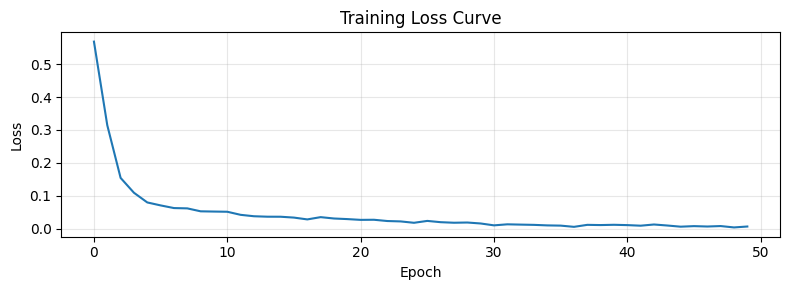

In [106]:
# ──────────────────────────────────────────────
# Complete Training Loop — Binary Classification
# ──────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.LongTensor(y_test)

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

model = SimpleNet(input_dim=30, hidden_dim=64, output_dim=2)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
for epoch in range(50):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

model.eval()
with torch.no_grad():
    outputs = model(X_test_t)
    _, predicted = torch.max(outputs, 1)
    accuracy = (predicted == y_test_t).sum().item() / len(y_test_t)

print(f"Test Accuracy: {accuracy:.4f}")

plt.figure(figsize=(8, 3))
plt.plot(train_losses)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [107]:
# ──────────────────────────────────────────────
# Custom Dataset + Model Save/Load
# ──────────────────────────────────────────────
import tempfile, os

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

ds = TabularDataset(X_train, y_train)
loader = DataLoader(ds, batch_size=32, shuffle=True)
print(f"Dataset: {len(ds)} samples, Batches: {len(loader)}")

# Save model
path = os.path.join(tempfile.gettempdir(), "model.pt")
torch.save(model.state_dict(), path)
print(f"Model saved ({os.path.getsize(path)/1024:.1f} KB)")

# Load model
m2 = SimpleNet(30, 64, 2)
m2.load_state_dict(torch.load(path, weights_only=True))
m2.eval()
with torch.no_grad():
    acc = (torch.max(m2(X_test_t),1)[1]==y_test_t).sum().item()/len(y_test_t)
print(f"Loaded model accuracy: {acc:.4f}")

Dataset: 455 samples, Batches: 15
Model saved (27.1 KB)
Loaded model accuracy: 0.9737


---

<a id="cnns"></a>

### Part 3: Convolutional Neural Networks (CNNs)


#### CNN Building Blocks

| Layer | Purpose | Key Parameters |
| --- | --- | --- |
| **Conv2d** | Extract spatial features using learnable filters | kernel_size, filters, stride, padding |
| **MaxPool2d** | Downsample feature maps (take max in window) | kernel_size, stride |
| **BatchNorm2d** | Normalize feature maps per batch | num_features |
| **Flatten** | Convert 2D feature maps to 1D vector | — |
| **Dropout2d** | Drop entire feature maps | p |

#### CNN Architectures Evolution

| Architecture | Year | Key Innovation | Depth |
| --- | --- | --- | --- |
| **LeNet-5** | 1998 | First practical CNN | 5 layers |
| **AlexNet** | 2012 | ReLU, dropout, GPU training | 8 layers |
| **VGG** | 2014 | Very deep, 3x3 convs only | 16-19 layers |
| **GoogLeNet** | 2014 | Inception modules (multi-scale) | 22 layers |
| **ResNet** | 2015 | Skip connections | 50-152 layers |
| **EfficientNet** | 2019 | Compound scaling | Variable |

Convolution output size = floor((W - K + 2P) / S) + 1

<div style="text-align:center">
<img src="https://cs231n.github.io/assets/cnn/convnet.jpeg" width="700" />
<br><em>CNN — Convolution → Pooling → Fully Connected layers</em>
</div>



#### CNN — Key Formulas

**Convolution output size:**

$$\text{output size} = \frac{W - K + 2P}{S} + 1$$

Where $W$ = input size, $K$ = kernel size, $P$ = padding, $S$ = stride.

**Number of parameters in Conv2d:**

$$\text{params} = (K \times K \times C_{in} + 1) \times C_{out}$$

Where +1 is for bias per filter.

**Receptive field:** How much of the input each neuron "sees". Grows with depth and kernel size.

**1×1 Convolution:** Reduces/expands channels without changing spatial dimensions. Used in Inception, ResNet bottleneck.

---

**Batch Normalization in CNNs:**

$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \quad y_i = \gamma \hat{x}_i + \beta$$

- $\mu_B, \sigma_B^2$ = batch mean/variance (training), running stats (inference)
- $\gamma, \beta$ = learnable scale and shift parameters


In [109]:
# ──────────────────────────────────────────────
# CNN in PyTorch — MNIST Classification
# ──────────────────────────────────────────────
import torchvision
import torchvision.transforms as transforms

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = CNN()
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test forward pass
x_test = torch.randn(2, 1, 28, 28)
print(f"Input: {x_test.shape} -> Output: {model(x_test).shape}")

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Parameters: 421,834
Input: torch.Size([2, 1, 28, 28]) -> Output: torch.Size([2, 10])


Epoch 1: Loss=0.1636, Acc=0.9498
Epoch 2: Loss=0.0629, Acc=0.9805
Epoch 3: Loss=0.0470, Acc=0.9857

Test Accuracy: 0.9879


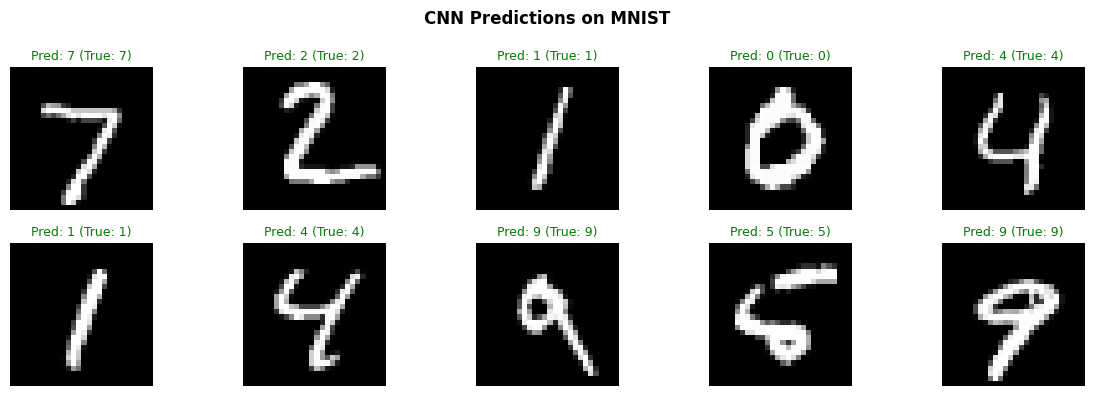

In [110]:
# ──────────────────────────────────────────────
# Train CNN on MNIST
# ──────────────────────────────────────────────
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

try:
    train_data = torchvision.datasets.MNIST('/tmp/data', train=True, download=True, transform=transform)
    test_data = torchvision.datasets.MNIST('/tmp/data', train=False, download=True, transform=transform)
    
    train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=256)
    
    model = CNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    for epoch in range(3):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for X_b, y_b in train_loader:
            optimizer.zero_grad()
            out = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct += out.argmax(1).eq(y_b).sum().item()
            total += y_b.size(0)
        print(f"Epoch {epoch+1}: Loss={total_loss/len(train_loader):.4f}, Acc={correct/total:.4f}")
    
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_b, y_b in test_loader:
            correct += model(X_b).argmax(1).eq(y_b).sum().item()
            total += y_b.size(0)
    print(f"\nTest Accuracy: {correct/total:.4f}")

    # Visualize predictions
    fig, axes = plt.subplots(2, 5, figsize=(12, 4))
    with torch.no_grad():
        for i, ax in enumerate(axes.flat):
            img, label = test_data[i]
            pred = model(img.unsqueeze(0)).argmax(1).item()
            ax.imshow(img.squeeze(), cmap='gray')
            color = 'green' if pred == label else 'red'
            ax.set_title(f"Pred: {pred} (True: {label})", color=color, fontsize=9)
            ax.axis('off')
    plt.suptitle('CNN Predictions on MNIST', fontweight='bold')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"MNIST: {e}")

---

<a id="transfer-learning"></a>

#### Transfer Learning and Fine-Tuning (PyTorch)

| Strategy | Description | When to Use |
| --- | --- | --- |
| **Feature extraction** | Freeze pretrained backbone, train new head | Small dataset, similar domain |
| **Fine-tuning** | Unfreeze some/all layers, low lr | Medium dataset |
| **Full training** | Train from scratch | Large dataset, very different domain |

In [111]:
# ──────────────────────────────────────────────
# Transfer Learning with ResNet-18 (PyTorch)
# ──────────────────────────────────────────────
from torchvision import models

resnet = models.resnet18(weights='DEFAULT')

# Feature extraction: freeze all, replace head
for param in resnet.parameters():
    param.requires_grad = False
resnet.fc = nn.Linear(resnet.fc.in_features, 10)

trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total = sum(p.numel() for p in resnet.parameters())
print(f"Feature extraction: {trainable:,} / {total:,} trainable ({100*trainable/total:.1f}%)")

# Fine-tuning: unfreeze layer4 + fc
resnet2 = models.resnet18(weights='DEFAULT')
for param in resnet2.parameters():
    param.requires_grad = False
for param in resnet2.layer4.parameters():
    param.requires_grad = True
resnet2.fc = nn.Linear(resnet2.fc.in_features, 10)

trainable2 = sum(p.numel() for p in resnet2.parameters() if p.requires_grad)
print(f"Fine-tuning (layer4+fc): {trainable2:,} / {total:,} trainable ({100*trainable2/total:.1f}%)")

Feature extraction: 5,130 / 11,181,642 trainable (0.0%)
Fine-tuning (layer4+fc): 8,398,858 / 11,181,642 trainable (75.1%)


---

<a id="rnns"></a>

### Part 4: RNNs, LSTMs, and GRUs

#### Vanilla RNN

$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$
$$y_t = W_{hy} h_t + b_y$$

**Problem**: Vanishing gradients — cannot learn long-range dependencies.

---

#### LSTM (Long Short-Term Memory)

LSTM solves vanishing gradients with a **cell state** $C_t$ and three gates:

$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f) \quad \text{(Forget gate — what to discard)}$$

$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i) \quad \text{(Input gate — what to store)}$$

$$\tilde{C}_t = \tanh(W_C [h_{t-1}, x_t] + b_C) \quad \text{(Candidate values)}$$

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t \quad \text{(Update cell state)}$$

$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o) \quad \text{(Output gate)}$$

$$h_t = o_t \odot \tanh(C_t) \quad \text{(Hidden state)}$$

---

#### GRU (Gated Recurrent Unit)

GRU simplifies LSTM with only 2 gates (fewer parameters, faster):

$$r_t = \sigma(W_r [h_{t-1}, x_t]) \quad \text{(Reset gate)}$$

$$z_t = \sigma(W_z [h_{t-1}, x_t]) \quad \text{(Update gate)}$$

$$\tilde{h}_t = \tanh(W [r_t \odot h_{t-1}, x_t]) \quad \text{(Candidate)}$$

$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t \quad \text{(Output)}$$

---

#### Recurrent Architecture Comparison

| Architecture | Gates | Parameters | Strengths | Weaknesses |
| --- | --- | --- | --- | --- |
| **Vanilla RNN** | None | Fewest | Simple | Vanishing gradient |
| **LSTM** | 3 (forget, input, output) | Most | Long-range dependencies | Slower, more params |
| **GRU** | 2 (reset, update) | Moderate | Faster than LSTM | Slightly less powerful |
| **Bidirectional** | Any | 2× base | Full context | Cannot do autoregressive |


<div style="text-align:center">
<img src="https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-chain.png" width="700" />
<br><em>LSTM Chain — forget, input, output gates with cell state (Source: colah.github.io)</em>
</div>


In [113]:
# ──────────────────────────────────────────────
# LSTM for Sequence Classification
# ──────────────────────────────────────────────

class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, bidirectional=False):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                           batch_first=True, bidirectional=bidirectional,
                           dropout=0.2 if num_layers > 1 else 0)
        factor = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_dim * factor, output_dim)
    
    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)
        if self.lstm.bidirectional:
            out = torch.cat((h_n[-2], h_n[-1]), dim=1)
        else:
            out = h_n[-1]
        return self.fc(out)

model = LSTMClassifier(10, 64, 2, 3, bidirectional=True)
x = torch.randn(4, 20, 10)  # batch=4, seq_len=20, features=10
print(f"Bi-LSTM: {x.shape} -> {model(x).shape}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Bi-LSTM: torch.Size([4, 20, 10]) -> torch.Size([4, 3])
Parameters: 138,627


---

<a id="transformers"></a>

### Part 5: Attention Mechanism and Transformers

#### Self-Attention (Scaled Dot-Product)

Given input $X$, we project into **Query**, **Key**, **Value**:

$$Q = XW_Q, \quad K = XW_K, \quad V = XW_V$$

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

Where $d_k$ is the dimension of keys (scaling prevents large dot products from pushing softmax to extremes).

---

#### Multi-Head Attention

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, ..., \text{head}_h) W^O$$

$$\text{where head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$

Each head learns different relationship patterns (syntax, semantics, positions).

---

#### Positional Encoding

Since Transformers have no recurrence, position must be encoded:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d}}\right), \quad PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$

---

#### Transformer Architecture

```
Input → Embedding + Positional Encoding
  ↓
N × [Multi-Head Attention → Add & Norm → FFN → Add & Norm]
  ↓
Output (Encoder) or Next Token (Decoder)
```

**Feed-Forward Network (FFN)** in each layer:

$$\text{FFN}(x) = \text{GELU}(xW_1 + b_1)W_2 + b_2$$

---

#### Transformer Model Comparison

| Model | Type | Pretraining | Use Case |
| --- | --- | --- | --- |
| **BERT** | Encoder | Masked LM + NSP | Classification, NER, QA |
| **GPT** | Decoder | Autoregressive (next token) | Text generation, chat |
| **T5** | Enc-Dec | Text-to-text | Translation, summarization |
| **ViT** | Encoder | Image patches as tokens | Image classification |
| **CLIP** | Dual encoder | Image-text contrastive | Cross-modal search |
| **LLaMA** | Decoder | Autoregressive | Open-source LLM |
| **Whisper** | Enc-Dec | Audio-text pairs | Speech recognition |


<div style="text-align:center">
<img src="https://machinelearningmastery.com/wp-content/uploads/2021/08/attention_research_1.png" width="400" />
<br><em>Transformer Architecture — Encoder + Decoder with Multi-Head Attention</em>
</div>


In [115]:
# ──────────────────────────────────────────────
# Multi-Head Self-Attention from Scratch (PyTorch)
# ──────────────────────────────────────────────

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_k = d_model // n_heads
        self.n_heads = n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
    
    def forward(self, x, mask=None):
        B, S, _ = x.shape
        Q = self.W_q(x).view(B, S, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(B, S, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, S, self.n_heads, self.d_k).transpose(1, 2)
        
        scores = (Q @ K.transpose(-2, -1)) / (self.d_k ** 0.5)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = F.softmax(scores, dim=-1)
        out = (attn @ V).transpose(1, 2).contiguous().view(B, S, -1)
        return self.W_o(out)

# Transformer Encoder Block
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_ff, d_model), nn.Dropout(dropout))
    
    def forward(self, x):
        x = self.norm1(x + self.attn(x))
        x = self.norm2(x + self.ffn(x))
        return x

# Stack encoder
class TransformerEncoder(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, n_layers, num_classes):
        super().__init__()
        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, d_ff) for _ in range(n_layers)])
        self.cls = nn.Linear(d_model, num_classes)
    
    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return self.cls(x.mean(dim=1))

enc = TransformerEncoder(64, 8, 256, 4, 10)
x = torch.randn(2, 20, 64)
print(f"Transformer Encoder: {x.shape} -> {enc(x).shape}")
print(f"Parameters: {sum(p.numel() for p in enc.parameters()):,}")

Transformer Encoder: torch.Size([2, 20, 64]) -> torch.Size([2, 10])
Parameters: 200,586


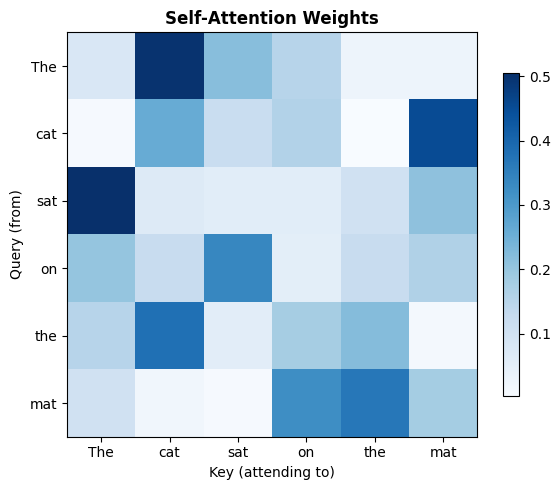

In [116]:
# ──────────────────────────────────────────────
# Attention Pattern Visualization
# ──────────────────────────────────────────────
tokens = ['The', 'cat', 'sat', 'on', 'the', 'mat']
n = len(tokens)

# Simulate attention weights
np.random.seed(42)
attn_weights = np.random.dirichlet(np.ones(n), size=n)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attn_weights, cmap='Blues', aspect='auto')
ax.set_xticks(range(n)); ax.set_xticklabels(tokens, fontsize=10)
ax.set_yticks(range(n)); ax.set_yticklabels(tokens, fontsize=10)
ax.set_xlabel('Key (attending to)')
ax.set_ylabel('Query (from)')
ax.set_title('Self-Attention Weights', fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

---

<a id="opencv"></a>

### Part 6: OpenCV — Computer Vision Basics

| Operation | Function | Description |
| --- | --- | --- |
| **Read** | cv2.imread(path) | Reads as BGR (not RGB) |
| **Color** | cv2.cvtColor(img, code) | BGR to RGB, grayscale, HSV |
| **Resize** | cv2.resize(img, (w, h)) | Resize with interpolation |
| **Edges** | cv2.Canny(img, low, high) | Edge detection |
| **Blur** | cv2.GaussianBlur(img, (k,k), sigma) | Gaussian smoothing |
| **Contours** | cv2.findContours(binary, mode, method) | Object boundaries |

In [117]:
# ──────────────────────────────────────────────
# OpenCV — Image Processing Demo
# ──────────────────────────────────────────────
try:
    import cv2
    img = np.zeros((200, 300, 3), dtype=np.uint8)
    cv2.rectangle(img, (50, 50), (250, 150), (0, 255, 0), 2)
    cv2.circle(img, (150, 100), 40, (255, 0, 0), -1)
    cv2.putText(img, 'OpenCV', (80, 190), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 3))
    for ax, (title, im, cm) in zip(axes, [
        ('Original', cv2.cvtColor(img, cv2.COLOR_BGR2RGB), None),
        ('Grayscale', gray, 'gray'), ('Canny Edges', edges, 'gray'),
        ('Gaussian Blur', blurred, 'gray')]):
        ax.imshow(im, cmap=cm); ax.set_title(title); ax.axis('off')
    plt.tight_layout(); plt.show()
except ImportError:
    print("OpenCV not installed: pip install opencv-python-headless")

OpenCV not installed: pip install opencv-python-headless


---

<a id="huggingface"></a>

### Part 7: HuggingFace Transformers Library

| Task | Model | Example |
| --- | --- | --- |
| **text-classification** | DistilBERT | Sentiment analysis |
| **token-classification** | BERT-NER | Named entity recognition |
| **question-answering** | BERT-QA | Extractive QA |
| **text-generation** | GPT-2 | Text completion |
| **zero-shot** | BART-MNLI | Classify without training |

In [118]:
# ──────────────────────────────────────────────
# HuggingFace — Pipelines + Tokenizer
# ──────────────────────────────────────────────
try:
    from transformers import pipeline, AutoTokenizer
    
    clf = pipeline('sentiment-analysis', model='distilbert-base-uncased-finetuned-sst-2-english')
    results = clf(['I love this!', 'This is terrible.', 'Not bad.'])
    print('Sentiment Analysis:')
    for r in results:
        print(f'  {r["label"]}: {r["score"]:.4f}')
    
    tok = AutoTokenizer.from_pretrained('bert-base-uncased')
    enc = tok('Hello, how are you?', return_tensors='pt')
    print(f'\nTokens: {tok.tokenize("Hello, how are you?")}')
    print(f'IDs shape: {enc["input_ids"].shape}')
except ImportError:
    print('transformers not installed')
except Exception as e:
    print(f'HuggingFace: {e}')

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1725.46it/s, Materializing param=pre_classifier.weight]                                  


Sentiment Analysis:
  POSITIVE: 0.9999
  NEGATIVE: 0.9996
  POSITIVE: 0.9995

Tokens: ['hello', ',', 'how', 'are', 'you', '?']
IDs shape: torch.Size([1, 8])


---

<a id="sentence-transformers"></a>

#### SentenceTransformers — Text Embeddings

| Concept | Description |
| --- | --- |
| **Sentence embedding** | Dense vector for entire sentence (384-768 dims) |
| **Bi-encoder** | Encode query and doc independently (fast) |
| **Cross-encoder** | Encode pair together (accurate, slow) |
| **Use cases** | Semantic search, clustering, duplicate detection |

In [119]:
# ──────────────────────────────────────────────
# SentenceTransformers — Semantic Similarity
# ──────────────────────────────────────────────
try:
    from sentence_transformers import SentenceTransformer, util
    model = SentenceTransformer('all-MiniLM-L6-v2')
    sents = ['ML is a subset of AI', 'AI includes ML and DL', 'I like pizza', 'Neural networks learn from data']
    embs = model.encode(sents, convert_to_tensor=True)
    sim = util.cos_sim(embs, embs)
    print(f'Embedding shape: {embs.shape}')
    print('\nSimilarity (>0.3):')
    for i in range(len(sents)):
        for j in range(i+1, len(sents)):
            s = sim[i][j].item()
            if s > 0.3:
                print(f'  [{s:.3f}] {sents[i][:35]} <-> {sents[j][:35]}')
except ImportError:
    print('sentence-transformers not installed')
except Exception as e:
    print(f'SentenceTransformers: {e}')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1947.11it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding shape: torch.Size([4, 384])

Similarity (>0.3):
  [0.656] ML is a subset of AI <-> AI includes ML and DL
  [0.351] ML is a subset of AI <-> Neural networks learn from data
  [0.334] AI includes ML and DL <-> Neural networks learn from data


---

<a id="dl-fundamentals-qa"></a>

#### DL Fundamentals — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | What is a neural network? | Neural network | • Network of connected artificial neurons in layers<br>• Input, hidden, output layers with learnable weights<br>• Universal approximation theorem |
| 2 | What is backpropagation? | Backprop, chain rule | • Compute gradients of loss w.r.t. all weights via chain rule<br>• Forward pass then backward pass<br>• Gradients used by optimizer to update weights |
| 3 | ReLU vs Sigmoid? | ReLU, sigmoid | • ReLU avoids vanishing gradient (gradient 0 or 1)<br>• Sigmoid saturates at extremes<br>• Dying ReLU: use Leaky ReLU |
| 4 | Vanishing gradient problem? | Vanishing, gradient | • Gradients shrink to near-zero in deep networks<br>• Solutions: ReLU, skip connections, batch norm, LSTM gates |
| 5 | What is batch normalization? | Batch norm | • Normalizes layer inputs per batch<br>• Faster convergence, allows higher lr<br>• Learnable gamma and beta |
| 6 | What is dropout? | Dropout, regularization | • Randomly zero neurons (p=0.2-0.5) during training<br>• Disabled during inference (model.eval()) |
| 7 | Adam vs SGD? | Adam, SGD | • Adam: adaptive lr, fast convergence<br>• SGD+momentum: better generalization for vision<br>• AdamW: Adam with proper weight decay |
| 8 | Epoch vs Batch vs Iteration? | Epoch, batch | • Epoch: full pass through data<br>• Batch: subset per step<br>• Iteration: one forward+backward on one batch |
| 9 | Weight initialization? | Init, Xavier, He | • Xavier: for sigmoid/tanh<br>• He/Kaiming: for ReLU<br>• Bad init causes vanishing/exploding gradients |
| 10 | What are skip connections? | Skip, ResNet | • y = F(x) + x; gradient flows through identity<br>• Enables 100+ layer networks (ResNet) |
| 11 | What is gradient clipping? | Clipping, exploding | • Limit gradient magnitude<br>• Essential for RNNs and LLMs |
| 12 | model.train() vs model.eval()? | Train, eval | • train(): dropout ON, batch norm uses batch stats<br>• eval(): dropout OFF, uses running stats |
| 13 | What is data augmentation? | Augmentation | • Random flip, rotate, crop, color jitter<br>• Increases effective dataset size; reduces overfitting |
| 14 | Cross-Entropy vs Focal Loss? | CE, focal | • CE: standard classification<br>• Focal: adds (1-p)^gamma; for imbalanced data |
| 15 | What is knowledge distillation? | Distillation | • Small student mimics large teacher<br>• Soft labels from high-temperature softmax |

---

<a id="pytorch-qa"></a>

#### PyTorch — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | What is a PyTorch Tensor? | Tensor | • Multi-dim array + GPU + autograd<br>• Like numpy ndarray with computation graph |
| 2 | What is autograd? | Autograd | • Auto differentiation; tracks ops on requires_grad=True<br>• .backward() computes gradients |
| 3 | Dynamic vs static graph? | Dynamic, eager | • PyTorch: graph built each forward pass (eager)<br>• Enables Python control flow in models<br>• Easier debugging |
| 4 | What is nn.Module? | Module | • Base class for all models<br>• Override __init__ and forward<br>• .parameters(), .to(device) |
| 5 | Why zero_grad()? | Zero grad | • PyTorch accumulates gradients by default<br>• Must reset before each batch |
| 6 | How to save/load models? | Save, state_dict | • torch.save(model.state_dict(), path)<br>• model.load_state_dict(torch.load(path)) |
| 7 | What is DataLoader? | DataLoader | • Batching, shuffling, parallel loading<br>• num_workers, pin_memory for speed |
| 8 | torch.no_grad()? | No grad | • Disable gradient computation for inference<br>• Saves memory |
| 9 | GPU usage in PyTorch? | CUDA, device | • model.to(device), data.to(device)<br>• Both must be on same device |
| 10 | nn.Sequential vs custom Module? | Sequential | • Sequential: linear stack<br>• Module: skip connections, custom logic |

---

<a id="cnn-rnn-qa"></a>

#### CNN and RNN — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | What is convolution? | Conv, filter | • Learnable filter slides across input (dot product)<br>• Output = (W-K+2P)/S + 1 |
| 2 | What is pooling? | Pooling, MaxPool | • Downsample feature maps; translation invariance<br>• MaxPool: take max in window |
| 3 | Receptive field? | Receptive, depth | • Input region influencing one output neuron<br>• Grows with depth |
| 4 | ResNet skip connections? | ResNet, skip | • y = F(x) + x; gradient highway<br>• Enables 100+ layer training |
| 5 | LSTM vs GRU? | LSTM, GRU | • LSTM: 3 gates + cell state; more powerful<br>• GRU: 2 gates; faster, fewer params |
| 6 | 1x1 convolution? | 1x1 conv | • Changes channels without spatial changes<br>• Dimensionality reduction |
| 7 | Depthwise separable conv? | Depthwise, MobileNet | • Split into depthwise + pointwise; 8-9x fewer params<br>• Used in MobileNet |
| 8 | Transfer learning? | Transfer, pretrained | • Use ImageNet-pretrained model<br>• Feature extraction or fine-tuning |
| 9 | Bidirectional RNN? | Bidirectional | • Process forward AND backward<br>• Full context; cannot do autoregressive |
| 10 | Why RNNs have vanishing gradients? | RNN, vanishing | • Gradient multiplied through many steps<br>• LSTM cell state acts as gradient highway |

---

<a id="transformers-qa"></a>

#### Transformers — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | What is self-attention? | Attention, QKV | • Each token attends to all others<br>• softmax(QK^T/sqrt(d_k)) * V |
| 2 | Why scale by sqrt(d_k)? | Scaling | • Prevent softmax saturation<br>• Keeps variance stable |
| 3 | Multi-head attention? | Multi-head | • Multiple attention ops in parallel<br>• Each learns different patterns |
| 4 | BERT vs GPT? | BERT, GPT | • BERT: encoder, bidirectional, understanding<br>• GPT: decoder, autoregressive, generation |
| 5 | Positional encoding? | Position, sinusoidal | • Adds position info (sin/cos or learned)<br>• Self-attention is permutation-invariant without it |
| 6 | Masked attention? | Masked, causal | • Triangular mask for autoregressive<br>• Essential for GPT |
| 7 | Vision Transformer? | ViT | • Image patches as tokens<br>• Competitive with CNNs on ImageNet |
| 8 | Sentence embeddings? | Embeddings | • Dense vector for sentence meaning<br>• SentenceTransformers for semantic search |

---

<a id="cv-qa"></a>

#### Computer Vision — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | OpenCV image format? | BGR, OpenCV | • Reads as BGR; convert with cvtColor<br>• Shape: (H, W, C) |
| 2 | Classification vs Detection vs Segmentation? | Detection, segmentation | • Classification: one label per image<br>• Detection: bounding boxes (YOLO)<br>• Segmentation: pixel-level |
| 3 | What is YOLO? | YOLO | • Single-pass detection; real-time<br>• Grid-based prediction |
| 4 | Feature extraction vs fine-tuning? | Extraction, tuning | • Extraction: freeze backbone, train head<br>• Fine-tuning: low lr on all layers |
| 5 | CNN architecture evolution? | LeNet, ResNet | • LeNet -> AlexNet -> VGG -> ResNet -> EfficientNet<br>• Key: ReLU, skip connections, scaling |

---

<a id="master-cheatsheet"></a>

### Master Interview Cheat Sheet — Deep Learning (PyTorch)

| # | Question | Answer |
|---|----------|--------|
| 1 | Neural network? | • Connected neuron layers; learns from data; universal approximation |
| 2 | Backpropagation? | • Chain rule for gradients; forward then backward pass |
| 3 | ReLU vs Sigmoid? | • ReLU: no vanishing gradient; Sigmoid: only for binary output |
| 4 | Batch normalization? | • Normalize per batch; faster convergence; slight regularizer |
| 5 | Dropout? | • Zero neurons (p=0.2-0.5) during training; ensemble effect |
| 6 | Adam vs SGD? | • Adam: adaptive, fast; SGD: better generalization for vision |
| 7 | PyTorch Tensor? | • Multi-dim array + GPU + autograd; like numpy with grad tracking |
| 8 | autograd? | • Auto differentiation; .backward() computes gradients |
| 9 | nn.Module? | • Override __init__ and forward; .parameters() for weights |
| 10 | Training loop steps? | • zero_grad -> forward -> loss -> backward -> step |
| 11 | model.train() vs eval()? | • train: dropout ON; eval: dropout OFF, running stats |
| 12 | DataLoader? | • Batching, shuffling, parallel loading; num_workers |
| 13 | Convolution? | • Learnable filter; output = (W-K+2P)/S + 1 |
| 14 | Pooling? | • MaxPool downsamples; translation invariance |
| 15 | ResNet? | • Skip connections: y=F(x)+x; 100+ layers possible |
| 16 | Transfer learning? | • Pretrained on ImageNet; freeze or fine-tune |
| 17 | LSTM vs GRU? | • LSTM: 3 gates, more powerful; GRU: 2 gates, faster |
| 18 | Self-attention? | • softmax(QK^T/sqrt(d_k))*V; all tokens attend to all |
| 19 | BERT vs GPT? | • BERT: encoder, bidirectional; GPT: decoder, autoregressive |
| 20 | Multi-head attention? | • Multiple parallel attention heads; different patterns |
| 21 | Positional encoding? | • sin/cos or learned; attention is position-agnostic |
| 22 | ViT? | • Image patches as tokens; standard transformer encoder |
| 23 | Save PyTorch model? | • torch.save(state_dict); checkpoint = model+optim+epoch |
| 24 | Gradient clipping? | • Limit magnitude; essential for RNNs/LLMs |
| 25 | Data augmentation? | • Random transforms; increases effective dataset size |
| 26 | 1x1 conv? | • Change channels; channel-wise FC layer |
| 27 | Knowledge distillation? | • Small student mimics large teacher; soft labels |
| 28 | Focal loss? | • (1-p)^gamma weighting; for imbalanced datasets |
| 29 | HuggingFace pipeline? | • Quick inference: pipeline(task, model) |
| 30 | Sentence embeddings? | • Dense vector (384-768d); semantic search, clustering |
| 31 | Bi-encoder vs Cross-encoder? | • Bi: fast retrieval; Cross: accurate reranking |
| 32 | Weight init? | • Xavier: sigmoid/tanh; He: ReLU; bad init = bad training |
| 33 | Cosine annealing? | • LR follows cosine from max to min |
| 34 | GELU? | • x*P(X<=x); default in transformers |
| 35 | Depthwise separable? | • 8-9x fewer params; MobileNet |

---
<a id="cnn-qa"></a>

#### CNN — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | Convolution operation? | Conv, filters | • Learnable filter slides over input doing element-wise multiply then sum<br>• Learns hierarchical features: edges -> textures -> objects<br>• Output size = (W-K+2P)/S + 1 |
| 2 | Stride effect? | Stride | • Stride=1: overlap fully; Stride=2: skip every other position<br>• Higher stride reduces output size (downsampling)<br>• Alternative to pooling for reducing spatial dimensions |
| 3 | Valid vs same padding? | Padding | • Valid: no padding, output shrinks<br>• Same: pad so output size = input size (pad=(K-1)/2)<br>• Same padding preserves spatial resolution |
| 4 | Receptive field? | Receptive field | • Input region that affects one output neuron<br>• Grows with depth: deeper layers see more of input<br>• Important for understanding what features each layer captures |
| 5 | Pooling and alternatives? | Pooling | • Reduces spatial dims; adds translation invariance<br>• MaxPool: take max in window (most common)<br>• Alternatives: strided convolutions, global average pooling |
| 6 | Global average pooling? | GAP | • Average entire feature map to single value per channel<br>• Replaces FC layers (fewer params, less overfitting)<br>• Used in modern architectures (ResNet, EfficientNet) |
| 7 | LeNet to ResNet evolution? | Architecture, evolution | • LeNet(1998): first practical CNN<br>• AlexNet(2012): ReLU + dropout + GPU<br>• VGG(2014): deep 3x3 convs; ResNet(2015): skip connections |
| 8 | Why VGG uses 3x3 only? | VGG, 3x3 | • Two 3x3 = one 5x5 receptive field but fewer params<br>• More non-linearities between layers<br>• Deeper with less computation |
| 9 | ResNet skip connections? | ResNet, residual | • y = F(x) + x (identity shortcut)<br>• Gradients flow directly through identity<br>• Enables training 100+ layers; won ImageNet 2015 |
| 10 | DenseNet vs ResNet? | DenseNet | • DenseNet: concatenate (not add) all previous layer outputs<br>• Feature reuse; fewer parameters<br>• ResNet: additive; DenseNet: concatenative |
| 11 | Depthwise separable convolution? | Depthwise, MobileNet | • Split conv: depthwise (spatial per channel) + pointwise (1x1 cross-channel)<br>• 8-9x fewer params and FLOPs<br>• MobileNet, EfficientNet use this |
| 12 | EfficientNet compound scaling? | EfficientNet | • Scale depth, width, AND resolution together<br>• Compound coefficient phi balances all three<br>• More efficient than scaling one dimension alone |
| 13 | 1x1 convolution? | 1x1 conv | • Changes number of channels without spatial changes<br>• Cross-channel feature combination<br>• Dimensionality reduction in Inception, ResNet bottleneck |
| 14 | Dilated/atrous convolution? | Dilated | • Gaps between kernel elements; expands receptive field<br>• No extra parameters or pooling<br>• Used in semantic segmentation (DeepLab) |
| 15 | Transposed convolution? | Transposed, upsampling | • Upsamples feature maps (learnable upsampling)<br>• Can cause checkerboard artifacts<br>• Alternative: bilinear upsample + regular conv |
| 16 | U-Net architecture? | U-Net, segmentation | • Encoder (downsample) + decoder (upsample) with skip connections<br>• Skip connections preserve fine-grained spatial info<br>• Standard for medical image segmentation |
| 17 | R-CNN to Faster R-CNN? | RCNN, detection | • R-CNN: extract regions, classify each (slow)<br>• Fast R-CNN: shared feature computation<br>• Faster R-CNN: Region Proposal Network (end-to-end) |
| 18 | YOLO? | YOLO, real-time | • Single pass: divide image into grid, predict boxes+classes per cell<br>• Real-time speed; slight accuracy tradeoff<br>• YOLOv5/v8 widely used in production |
| 19 | Non-Maximum Suppression? | NMS | • Remove duplicate/overlapping detections after detection<br>• Keep highest confidence; remove if IoU > threshold<br>• Essential post-processing step |
| 20 | Vision Transformer vs CNN? | ViT, CNN | • ViT: image patches as tokens; global attention from start<br>• CNN: local features, hierarchical; ViT: global but needs more data<br>• ViT with pretraining matches/beats CNNs |
| 21 | Data augmentation for images? | Augmentation, images | • Geometric: flip, rotate, crop, resize<br>• Color: jitter, normalize, grayscale<br>• Advanced: Cutout, MixUp, CutMix, AutoAugment |
| 22 | CutMix vs MixUp? | CutMix, MixUp | • MixUp: blend two images and labels (alpha*img1 + (1-alpha)*img2)<br>• CutMix: paste patch from one onto another<br>• CutMix preserves local structure better |
| 23 | Focal loss for detection? | Focal loss | • (1-p)^gamma * CE; down-weights easy examples<br>• Addresses extreme class imbalance in detection (many background boxes)<br>• RetinaNet introduced focal loss |

---
<a id="rnn-qa"></a>

#### RNN and Sequence Models — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | What is an RNN? | RNN | • Neural network with recurrent connections (hidden state)<br>• Processes sequences element by element; h_t = f(W*[h_{t-1}, x_t])<br>• Shares weights across time steps |
| 2 | Why RNNs have vanishing gradients? | RNN, vanishing | • Gradient multiplied through many time steps (long chain rule)<br>• If gradient < 1 at each step: vanishes exponentially<br>• LSTM/GRU solve with gating mechanisms |
| 3 | LSTM gates walkthrough? | LSTM, gates | • Forget gate: decides what to discard from cell state<br>• Input gate: decides what new info to store<br>• Output gate: decides what to output<br>• Cell state: long-range memory highway |
| 4 | GRU vs LSTM? | GRU, LSTM | • GRU: 2 gates (reset, update) vs LSTM 3 gates + cell state<br>• GRU: fewer params, faster training<br>• LSTM: slightly more powerful on long sequences |
| 5 | Bidirectional RNN? | Bidirectional | • Process forward AND backward; concatenate hidden states<br>• Full context for each position<br>• Cannot do autoregressive generation |
| 6 | Seq2Seq architecture? | Seq2Seq, encoder-decoder | • Encoder: process input sequence, produce context vector<br>• Decoder: generate output sequence from context<br>• Foundation for machine translation pre-Transformer |
| 7 | Teacher forcing? | Teacher forcing | • During training: feed ground truth as decoder input (not prediction)<br>• Speeds up training but creates exposure bias<br>• Inference: must use own predictions (mismatch) |
| 8 | Why Transformers replaced RNNs? | Transformer, RNN | • Transformers: parallel processing (not sequential)<br>• Self-attention captures long-range dependencies directly<br>• Much faster training; scales better |
| 9 | Beam search? | Beam search | • Keep top-k candidates at each decoding step<br>• Explores more of output space than greedy<br>• beam_size=1: greedy; larger: better but slower |
| 10 | Temperature in generation? | Temperature | • T < 1: sharper distribution (more confident, less diverse)<br>• T > 1: flatter distribution (more random, more diverse)<br>• T = 0: greedy (argmax) |
| 11 | Top-k vs top-p sampling? | Top-k, nucleus | • Top-k: sample from k highest-probability tokens<br>• Top-p (nucleus): sample from smallest set summing to p probability<br>• Top-p more adaptive (varies k based on distribution shape) |
| 12 | Bahdanau attention? | Bahdanau | • First attention mechanism for Seq2Seq<br>• Decoder attends to all encoder hidden states (not just last)<br>• Learns alignment between input and output positions |

---
<a id="transformers-qa"></a>

#### Attention and Transformers — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | What is self-attention? | Self-attention | • Each token computes attention to all other tokens<br>• Attention(Q,K,V) = softmax(QK^T/sqrt(d_k))V<br>• Captures relationships regardless of distance |
| 2 | Why divide by sqrt(d_k)? | Scaling, sqrt | • Large d_k: dot products grow large, softmax saturates<br>• Division keeps variance stable<br>• Prevents gradient vanishing through softmax |
| 3 | Multi-head attention? | Multi-head | • Multiple attention operations in parallel (8-32 heads typical)<br>• Each head learns different patterns/relationships<br>• Concatenate and project: MultiHead = Concat(head_1,...,head_h)W_O |
| 4 | Encoder vs decoder? | Encoder, decoder | • Encoder: bidirectional attention (sees all tokens)<br>• Decoder: causal/masked attention (sees only past tokens)<br>• Cross-attention connects decoder to encoder |
| 5 | Positional encoding? | Position, sinusoidal | • Self-attention is permutation-invariant (no position info)<br>• Sinusoidal: fixed sin/cos functions; Learned: trained embeddings<br>• RoPE: rotary (modern LLMs); ALiBi: attention biases |
| 6 | RoPE? | RoPE, rotary | • Rotary Position Embedding: encode position via rotation matrices<br>• Relative position naturally captured in dot product<br>• Extrapolates to longer sequences; used in LLaMA, Mistral |
| 7 | Pre-LayerNorm vs Post-LayerNorm? | LayerNorm | • Post-LN (original): harder to train, needs warmup<br>• Pre-LN: more stable training, no warmup needed<br>• Pre-LN dominant in modern Transformers |
| 8 | Masked/causal attention? | Causal, masked | • Upper-triangular mask prevents attending to future tokens<br>• Essential for autoregressive generation (GPT)<br>• Each position only sees itself and earlier positions |
| 9 | Cross-attention? | Cross-attention | • Query from decoder, Key/Value from encoder<br>• How decoder reads encoder output<br>• Used in encoder-decoder models (T5, translation) |
| 10 | BERT vs GPT vs T5? | BERT, GPT, T5 | • BERT: encoder-only, bidirectional, understanding tasks<br>• GPT: decoder-only, autoregressive, generation tasks<br>• T5: encoder-decoder, text-to-text framework |
| 11 | O(n^2) attention complexity? | Complexity, quadratic | • Each token attends to all n tokens: n^2 attention scores<br>• Limits context length (memory and compute)<br>• Solutions: sparse, linear attention, Flash Attention |
| 12 | Flash Attention? | Flash Attention | • Exact attention with IO-aware tiling algorithm<br>• No approximation, just memory-efficient computation<br>• 2-4x speedup by reducing GPU memory reads/writes |
| 13 | KV cache? | KV cache | • Cache Key and Value tensors from previous positions<br>• Avoid recomputing for autoregressive generation<br>• Critical for efficient inference; trades memory for compute |
| 14 | MQA and GQA? | MQA, GQA | • Multi-Query Attention: single KV head shared across query heads<br>• Grouped-Query Attention: few KV heads (groups of queries share)<br>• Reduces KV cache memory significantly |
| 15 | BERT pre-training? | MLM, NSP | • Masked Language Model: predict randomly masked tokens (15%)<br>• NSP: predict if sentence B follows A (later found unnecessary)<br>• [CLS] for classification, [SEP] for sentence boundary |
| 16 | BERT variants? | RoBERTa, DistilBERT | • RoBERTa: more data, no NSP, dynamic masking<br>• DistilBERT: knowledge distillation (60% size, 97% performance)<br>• DeBERTa: disentangled attention + enhanced mask decoder |
| 17 | GPT architecture? | GPT, autoregressive | • Decoder-only Transformer; predict next token<br>• Pre-trained on massive text corpus<br>• In-context learning: zero/few-shot via prompting |
| 18 | Emergent abilities in LLMs? | Emergent | • Capabilities appearing only at certain scale (not in smaller models)<br>• Chain-of-thought reasoning, code generation, translation<br>• Sudden jumps in capability with more parameters |
| 19 | Instruction tuning? | Instruction tuning | • Fine-tune LLM on instruction-response pairs<br>• Makes model follow user instructions instead of just completing text<br>• Foundation of ChatGPT-like models |
| 20 | RLHF explained? | RLHF, PPO | • 1. SFT: supervised fine-tuning on demos<br>• 2. Train reward model on human preferences<br>• 3. PPO: optimize policy using reward model<br>• Aligns model with human preferences |
| 21 | DPO vs PPO? | DPO | • DPO: Direct Preference Optimization — no reward model needed<br>• Optimize policy directly from preference pairs<br>• Simpler, more stable than PPO |
| 22 | Mixture of Experts? | MoE, routing | • Multiple expert sub-networks; router selects top-K per token<br>• Scale model capacity without proportional compute<br>• Used in Mixtral, Switch Transformer |
| 23 | Chain-of-thought prompting? | CoT | • Ask model to reason step-by-step before answering<br>• Dramatically improves reasoning on math, logic tasks<br>• Zero-shot CoT: just add "Let's think step by step" |
| 24 | BPE tokenization? | BPE, tokenizer | • Byte-Pair Encoding: iteratively merge most frequent pairs<br>• Subword tokenization: handles rare words, morphology<br>• Vocabulary size tradeoff: small = long sequences; large = sparse |
| 25 | Model vs data parallelism? | Parallelism | • Data: same model on multiple GPUs, different data<br>• Model: split model across GPUs (tensor, pipeline parallelism)<br>• Large models need both (FSDP, DeepSpeed) |

---
<a id="genai-qa"></a>

#### Generative AI and Multimodal — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | GAN architecture? | GAN, generator | • Generator creates fake data; Discriminator classifies real vs fake<br>• Adversarial training: minimax game<br>• Generator wins when Discriminator can't distinguish |
| 2 | Mode collapse in GANs? | Mode collapse | • Generator produces limited variety of outputs<br>• Fixes: diverse training, Wasserstein loss, progressive growing<br>• Diffusion models largely replaced GANs |
| 3 | VAE explained? | VAE, latent | • Encoder maps input to latent distribution (mean, variance)<br>• Reparameterization trick: z = mu + sigma * epsilon<br>• Output is smooth latent space; decoded back to data |
| 4 | Diffusion models? | Diffusion, DDPM | • Forward: gradually add noise until pure noise<br>• Reverse: learn to denoise step by step<br>• Higher quality than GANs; stable training |
| 5 | Stable Diffusion? | Stable Diffusion | • Latent diffusion: work in compressed latent space (not pixel space)<br>• Text encoder (CLIP) + U-Net denoiser + VAE decoder<br>• Classifier-free guidance controls text-image alignment |
| 6 | Classifier-free guidance? | CFG, guidance | • Scale: interpolate between conditional and unconditional generation<br>• Higher guidance = more aligned to prompt, less diversity<br>• Typical: 7-15 for good balance |
| 7 | ControlNet? | ControlNet | • Add spatial conditioning (edges, poses, depth) to diffusion models<br>• Zero convolution: trainable copy of encoder<br>• Enables precise structural control |
| 8 | What is CLIP? | CLIP, contrastive | • Contrastive Language-Image Pre-training<br>• Aligns text and image embeddings in shared space<br>• Enables zero-shot image classification via text |
| 9 | Vision-Language Models? | VLM, multimodal | • Process both images and text (GPT-4V, LLaVA)<br>• Image tokenized via vision encoder (ViT/CLIP)<br>• Projected into LLM embedding space |
| 10 | FID score? | FID, evaluation | • Frechet Inception Distance: compare stats of real vs generated images<br>• Lower FID = more realistic generation<br>• Uses Inception network features |
| 11 | LoRA for image gen? | LoRA, SD | • Fine-tune Stable Diffusion with low-rank adapters<br>• Train specific styles/characters with few images<br>• Small file size (few MB vs full model GB) |
| 12 | DreamBooth? | DreamBooth | • Personalize image gen: learn a unique subject from few images<br>• Fine-tunes entire model with prior preservation loss<br>• "A [V] dog in the style of Van Gogh" |

---
<a id="hf-qa"></a>

#### HuggingFace Ecosystem — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | What is HuggingFace? | HuggingFace, hub | • Open-source ML platform: models, datasets, spaces<br>• 500K+ models; standardized API (AutoModel, pipeline)<br>• Central hub for modern ML/AI development |
| 2 | AutoModel and from_pretrained? | AutoModel | • Auto-selects architecture from model name<br>• Downloads weights + config from Hub<br>• AutoTokenizer, AutoModelForSequenceClassification, etc. |
| 3 | pipeline API? | pipeline | • Quick inference: pipeline(task, model=name)<br>• Tasks: classification, NER, QA, generation, summarization<br>• Good for prototyping; wraps tokenizer + model + postprocessing |
| 4 | Trainer API? | Trainer | • Handles training loop, evaluation, logging, checkpointing<br>• TrainingArguments: lr, epochs, batch_size, warmup, weight_decay<br>• Integrates with W&B, TensorBoard |
| 5 | Datasets library? | Datasets, arrow | • Efficient data loading using Apache Arrow (memory-mapped)<br>• .map(): apply transforms; .filter(): subset data<br>• Handles datasets larger than RAM |
| 6 | PEFT library? | PEFT, LoRA | • Parameter-Efficient Fine-Tuning: LoRA, prefix tuning, adapters<br>• Train only small number of params<br>• get_peft_model(model, LoraConfig(...)) |
| 7 | TRL library? | TRL, RLHF | • Transformer Reinforcement Learning: SFT, RLHF, DPO training<br>• SFTTrainer for supervised fine-tuning<br>• DPOTrainer for preference alignment |
| 8 | Quantization on HF? | bitsandbytes, quantize | • bitsandbytes: 8-bit/4-bit loading (load_in_8bit=True)<br>• GPTQ: post-training quantization (predictive)<br>• AWQ: activation-aware weight quantization |
| 9 | SafeTensors? | SafeTensors | • Safe serialization format (no arbitrary code execution)<br>• Faster loading than pickle-based formats<br>• Default on HuggingFace Hub |
| 10 | Text Generation Inference? | TGI, vLLM | • Optimized serving for LLMs (continuous batching, tensor parallelism)<br>• vLLM: PagedAttention for memory efficiency<br>• Both production-ready for high-throughput inference |

---
<a id="master-cheatsheet"></a>

### Master Interview Cheat Sheet — Deep Learning

| # | Question | Answer |
|---|----------|--------|
| 1 | What is Deep Learning? | • Multi-layer neural networks; learns hierarchical representations automatically |
| 2 | Backpropagation? | • Chain rule computes gradients; forward -> loss -> backward -> update |
| 3 | ReLU vs Sigmoid? | • ReLU: no vanishing gradient, default hidden; Sigmoid: binary output only |
| 4 | Batch normalization? | • Normalizes per batch; faster convergence, higher lr; train vs eval behavior |
| 5 | Dropout? | • Zero random neurons (p=0.2-0.5); ensemble effect; off during eval |
| 6 | Adam vs SGD? | • Adam: adaptive, fast (NLP); SGD+momentum: generalizes better (vision) |
| 7 | Transfer learning? | • Pretrained model + new head; feature extraction or fine-tuning |
| 8 | Label smoothing? | • Soft labels (0.1, 0.9); prevents overconfidence; better calibration |
| 9 | Knowledge distillation? | • Student learns from teacher's soft predictions at high temperature |
| 10 | Gradient clipping? | • Cap gradient norm; essential for RNNs and LLM training |
| 11 | PyTorch Tensor? | • Multi-dim array + GPU + autograd; like numpy with grad tracking |
| 12 | autograd? | • Dynamic graph; .backward() computes gradients via chain rule |
| 13 | nn.Module? | • Override __init__ + forward; call model(x) not model.forward(x) |
| 14 | Training loop? | • train() -> zero_grad -> forward -> loss -> backward -> step |
| 15 | DDP vs DataParallel? | • DDP: multi-process, preferred; DataParallel: single-process, GIL bottleneck |
| 16 | Mixed precision? | • FP16 compute, FP32 updates; torch.amp; 2x faster, 2x less memory |
| 17 | Convolution? | • Learnable filter; output = (W-K+2P)/S + 1; hierarchical features |
| 18 | ResNet? | • y=F(x)+x skip connections; enables 100+ layers; gradient highway |
| 19 | 1x1 conv? | • Cross-channel mixing; dimensionality reduction; Inception blocks |
| 20 | LSTM vs GRU? | • LSTM: 3 gates + cell state; GRU: 2 gates, faster, slightly weaker |
| 21 | Self-attention? | • softmax(QK^T/sqrt(d_k))V; global relationships; quadratic complexity |
| 22 | Multi-head attention? | • Multiple parallel heads; each learns different patterns; concat output |
| 23 | BERT vs GPT? | • BERT: encoder, bidirectional, understanding; GPT: decoder, autoregressive |
| 24 | RLHF? | • SFT -> reward model -> PPO; aligns LLM with human preferences |
| 25 | DPO? | • Direct preference optimization; no reward model; simpler than PPO |
| 26 | Flash Attention? | • IO-aware exact attention; 2-4x faster; no quality loss |
| 27 | KV cache? | • Cache past keys/values; avoid recomputation in autoregressive gen |
| 28 | LoRA? | • Low-rank adapters for efficient fine-tuning; few % of params |
| 29 | Diffusion models? | • Add noise then learn to denoise; higher quality than GANs |
| 30 | CLIP? | • Contrastive image-text alignment; zero-shot classification |
| 31 | HuggingFace pipeline? | • Quick inference: pipeline(task, model); wraps tokenizer+model |
| 32 | Trainer API? | • Handles training loop, eval, checkpoints, logging integration |
| 33 | torch.compile? | • PyTorch 2.0; graph optimization; 30-200% speedup |
| 34 | Gradient checkpointing? | • Recompute activations during backward; trade compute for memory |
| 35 | MoE? | • Multiple experts; router selects top-K per token; scales capacity |
| 36 | Chain-of-thought? | • Step-by-step reasoning; dramatically improves LLM problem solving |
| 37 | Quantization? | • Reduce precision (32->8 or 4 bit); smaller, faster; slight quality loss |
| 38 | vLLM? | • PagedAttention LLM serving; continuous batching; high throughput |
| 39 | SafeTensors? | • Safe serialization; no pickle exploits; faster loading |
| 40 | BPE tokenization? | • Subword: merge frequent pairs; handles rare words; vocab tradeoff |